In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tickers = ["SPY", "QQQ"]
data = yf.download(tickers, start="2007-01-01", end="2009-12-31")["Close"]

returns = np.log(data / data.shift(1)).dropna()


[*********************100%***********************]  2 of 2 completed


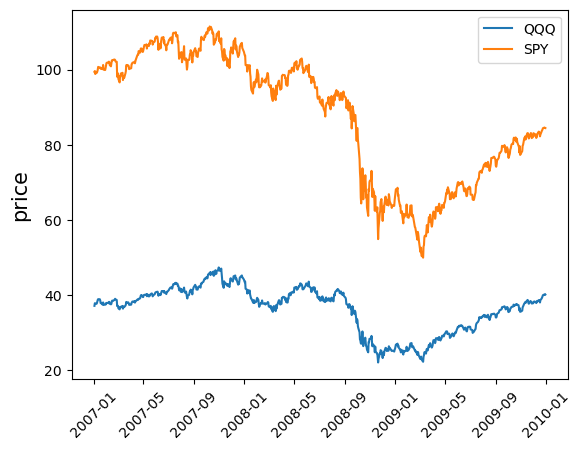

In [2]:
plt.plot(data, label=data.columns)
plt.legend()
plt.xticks(rotation=45)
plt.ylabel("price", fontsize=15)
plt.show()

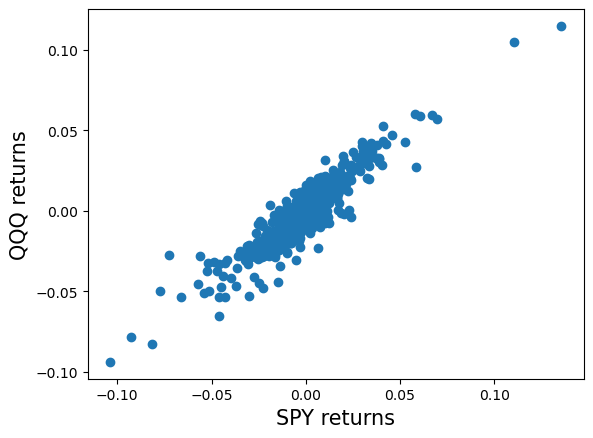

In [3]:
plt.scatter(returns[tickers[0]],returns[tickers[1]])
plt.xlabel(f'{tickers[0]} returns', fontsize=15)
plt.ylabel(f'{tickers[1]} returns', fontsize=15)
plt.show()

In [4]:
from scipy.stats import rankdata

# convert to rank ordering and make a numpy array
# treat as if sampling from a rectangular distribution

U = returns.apply(lambda x: rankdata(x) / (len(x) + 1))
U = U.values


In [5]:
# fit Gaussian
# convert rectangular distribution into a Gaussian
from scipy.stats import norm, multivariate_normal

Z = norm.ppf(U)
rho = np.corrcoef(Z.T)[0, 1]

ll_gaussian = np.sum(
    multivariate_normal.logpdf(Z, mean=[0, 0], cov=[[1, rho], [rho, 1]])
)


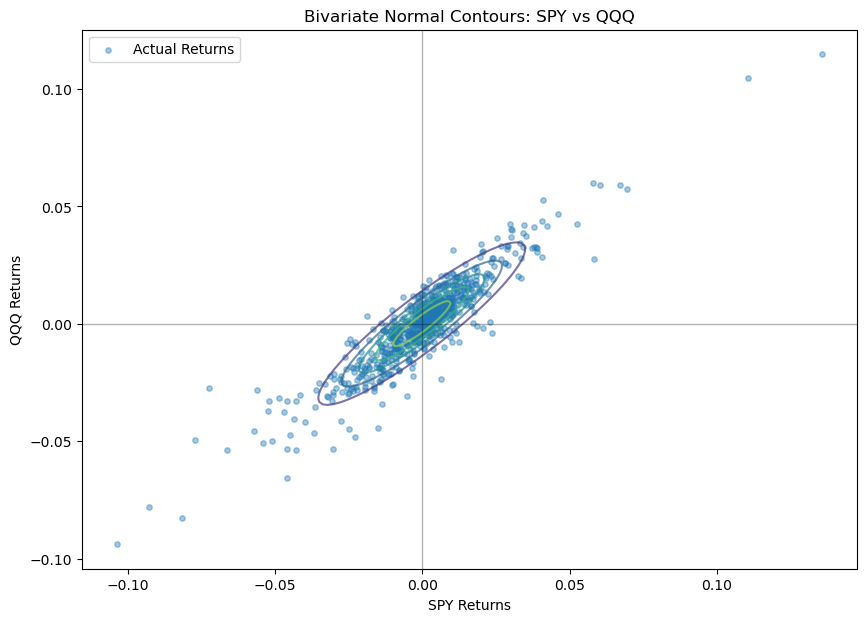

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 1. Calculate stats from your DataFrame
# We use the first two tickers as requested
t0, t1 = tickers[0], tickers[1]
mu = returns[[t0, t1]].mean().values
sigma = returns[[t0, t1]].cov().values
stds = returns[[t0, t1]].std().values

# 2. Define grid limits based on the standard deviations (e.g., +/- 3 sigma)
max_sigma = 3
x_min, x_max = mu[0] - max_sigma*stds[0], mu[0] + max_sigma*stds[0]
y_min, y_max = mu[1] - max_sigma*stds[1], mu[1] + max_sigma*stds[1]

x = np.linspace(x_min, x_max, 100)
y = np.linspace(y_min, y_max, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# 3. Create the distribution and PDF
rv = multivariate_normal(mu, sigma)
Z = rv.pdf(pos)

# 4. Plotting
plt.figure(figsize=(10, 7))

# Plot contours with levels that make sense for the density scale
plt.contour(X, Y, Z, levels=6, cmap='viridis', alpha=0.7)

# Overlay the scatterplot
plt.scatter(returns[t0], returns[t1], alpha=0.4, s=15, label='Actual Returns')

plt.title(f'Bivariate Normal Contours: {t0} vs {t1}')
plt.xlabel(f'{t0} Returns')
plt.ylabel(f'{t1} Returns')
plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)
plt.legend()
plt.show()

    Calculate the likelihood of the bivariate Student's t-distribution
    by subtracting the sum of the log marginal densities from the log joint density:
$$L(\theta) = -\sum (\ln f_{joint}(Z) - \sum \ln f_{marginal}(Z_i))$$

In [7]:
# fit t-Copula
from scipy.stats import t
from scipy.optimize import minimize

def neg_log_likelihood(params):
    """
    Calculate the negative log-likelihood for a bivariate Student's t-distribution model.

    This function transforms uniform marginals (U) into a bivariate space using 
    the Percent Point Function (inverse CDF) of a Student's t-distribution, 
    then computes the likelihood based on a specified correlation (rho) 
    and degrees of freedom (nu).

    Parameters
    ----------
    params : array-like
        A sequence containing:
        * rho (float): The correlation coefficient between the two variables. 
          Must be in the open interval (-1, 1).
        * nu (float): The degrees of freedom for the t-distribution. 
          Must be > 2 to ensure finite variance.

    Returns
    -------
    float
        The negative log-likelihood. Returns `np.inf` if parameters are 
        outside valid bounds (e.g., |rho| >= 1 or nu <= 2).


    """
    rho, nu = params

    if abs(rho) >= 1 or nu <= 2:
        return np.inf

    # convert rectangular distribution to a t-distribution
    Z = t.ppf(U, df=nu)
    cov = [[1, rho], [rho, 1]]

    joint = multivariate_normal.logpdf(
        Z,
        mean=[0, 0],
        cov=cov
    )

    marginals = t.logpdf(Z[:,0], nu) + t.logpdf(Z[:,1], nu)

    return -np.sum(joint - marginals)

# fit correlation (bivariate Gaussian) and
# number of degrees of freedom for t-distributions

res = minimize(
    neg_log_likelihood,
    x0=[0.5, 5],
    bounds=[(-0.99, 0.99), (2.1, 50)]
)

print(res)
rho, df = res['x']
print(f"\nbest estimates for rho = {rho:0.4f}, t-distribution df = {df:0.4f}\n")

ll_tcopula = -res.fun

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -614.5577453170933
        x: [ 8.863e-01  1.565e+01]
      nit: 10
      jac: [ 1.251e-03 -4.547e-05]
     nfev: 66
     njev: 22
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

best estimates for rho = 0.8863, t-distribution df = 15.6505



In [8]:
# goodness of fit
AIC_gaussian = 2*1 - 2*ll_gaussian      # 1 parameter (rho)
AIC_tcopula  = 2*2 - 2*ll_tcopula       # rho + nu

print("Gaussian Copula AIC:", AIC_gaussian)
print("t-Copula AIC:", AIC_tcopula)

print(f"\n{'t-Copula' if AIC_tcopula < AIC_gaussian else 'Gaussian Copula'} is a better fit\n")


Gaussian Copula AIC: 3045.7107348928266
t-Copula AIC: -1225.1154906341867

t-Copula is a better fit



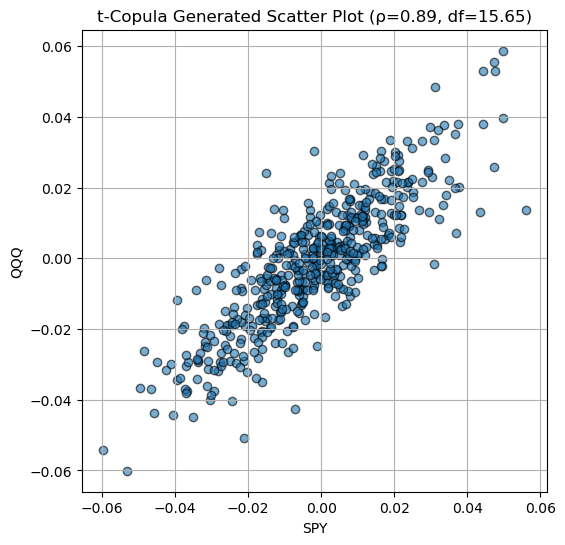

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_t, t

def generate_t_copula(n=500, rho=0.7, df=5, random_state=None):
    """
    Generate samples from a bivariate t-copula.

    Parameters
    ----------
    n : int
        Number of samples
    rho : float
        Correlation parameter (-1 < rho < 1)
    df : int
        Degrees of freedom for the t distribution
    random_state : int or None
        Random seed

    Returns
    -------
    U : ndarray (n, 2)
        Samples from the t-copula (uniform marginals)
    """
    if random_state is not None:
        np.random.seed(random_state)

    # Correlation matrix
    corr = np.array([[1.0, rho],
                     [rho, 1.0]])

    # Draw from bivariate t distribution
    t_samples = multivariate_t.rvs(
        loc=[0, 0],
        shape=corr,
        df=df,
        size=n
    )

    U = t_samples# t.cdf(t_samples, df=df)

    return U

N = 500

# Generate copula samples
U = generate_t_copula(n=N, rho=rho, df=df, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(U[:, 0] * stds[0], U[:, 1] * stds[1], alpha=0.6, edgecolor="k")
plt.xlabel(tickers[0])
plt.ylabel(tickers[1])
plt.title(f"t-Copula Generated Scatter Plot (ρ={rho:0.2f}, df={df:0.2f})")
plt.grid(True)
plt.show()


In [10]:
# empirical copula
def empirical_copula(U):
    n = U.shape[0]
    C = np.zeros(n)

    for i in range(n):
        C[i] = np.mean(
            (U[:, 0] <= U[i, 0]) &
            (U[:, 1] <= U[i, 1])
        )
    return C


In [11]:
# fitted copula
from scipy.stats import norm, multivariate_normal

def gaussian_copula_cdf(U, rho):
    Z = norm.ppf(U)
    mvn = multivariate_normal(
        mean=[0, 0],
        cov=[[1, rho], [rho, 1]]
    )

    return np.array([
        mvn.cdf(z) for z in Z
    ])


In [12]:
# t copula
from scipy.stats import t

def t_copula_cdf(U, rho, nu):
    Z = t.ppf(U, df=nu)
    mvn = multivariate_normal(
        mean=[0, 0],
        cov=[[1, rho], [rho, 1]]
    )

    return np.array([
        mvn.cdf(z) for z in Z
    ])


In [13]:
# comparison
C_emp = empirical_copula(U)

C_gauss = gaussian_copula_cdf(U, rho)
C_t = t_copula_cdf(U, res.x[0], res.x[1])

KS_gaussian = np.max(np.abs(C_emp - C_gauss))
KS_tcopula  = np.max(np.abs(C_emp - C_t))

print("KS Gaussian copula:", KS_gaussian)
print("KS t-copula:", KS_tcopula)


KS Gaussian copula: 0.996
KS t-copula: 0.996


In [14]:
# compute t values
def bootstrap_ks(U, copula_cdf, params, B=500):
    n = U.shape[0]
    ks_stats = []

    for _ in range(B):
        idx = np.random.choice(n, n, replace=True)
        U_b = U[idx]

        C_emp_b = empirical_copula(U_b)
        C_model_b = copula_cdf(U_b, *params)

        ks_stats.append(np.max(np.abs(C_emp_b - C_model_b)))

    return np.array(ks_stats)


In [15]:
boot_gauss = bootstrap_ks(U, gaussian_copula_cdf, (rho,))
boot_t = bootstrap_ks(U, t_copula_cdf, res.x)

p_gauss = np.mean(boot_gauss >= KS_gaussian)
p_t = np.mean(boot_t >= KS_tcopula)

print("Gaussian copula p-value:", p_gauss)
print("t-copula p-value:", p_t)


Gaussian copula p-value: 0.562
t-copula p-value: 0.54
